<a href="https://colab.research.google.com/github/tepherve-cmyk/DAAI_Project_HT/blob/main/Project5_Herve_Tepongning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## FINAL PROJECT
#Project Part 5

Name: Herve Tepongning Megnifo

Student Number: HT137724

Program: Business Intelligence Analyst

Course: Data Analytics and Artificial Intelligence Project

## Introduction



The main objective of this project is to use NLP and unsupervised learning to explore patterns within text data.

The project uses the 20 Newsgroups dataset, which contains approximately 20,000 documents across 20 different topics. Clustering techniques are used to identify patterns in the text without using predefined categories.

Part A: Load and Explore the Data

Load the dataset

In [1]:
from sklearn.datasets import fetch_20newsgroups

# Load the training dataset
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

# Store the documents and category labels
documents = newsgroups.data
labels = newsgroups.target
categories = newsgroups.target_names

print("Number of documents:", len(documents))
print("Number of categories:", len(categories))

Number of documents: 11314
Number of categories: 20


Display the categories

In [2]:
# Display the Newsgroup Categories

print("Category names:")
for i, category in enumerate(categories):
    print(i, category)

Category names:
0 alt.atheism
1 comp.graphics
2 comp.os.ms-windows.misc
3 comp.sys.ibm.pc.hardware
4 comp.sys.mac.hardware
5 comp.windows.x
6 misc.forsale
7 rec.autos
8 rec.motorcycles
9 rec.sport.baseball
10 rec.sport.hockey
11 sci.crypt
12 sci.electronics
13 sci.med
14 sci.space
15 soc.religion.christian
16 talk.politics.guns
17 talk.politics.mideast
18 talk.politics.misc
19 talk.religion.misc


Display documents

In [3]:
# Display Three Example Documents

for i in range(3):
    print(f"\n--- Document {i + 1} ---")
    print(documents[i][:1000])


--- Document 1 ---
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

--- Document 2 ---
A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the next two days, so please add to the network
knowledge base if you have done the clock u

Check the dataset structure

In [4]:
# Check the Dataset Structure

print("Type of documents:", type(documents))
print("Type of labels:", type(labels))
print("Number of documents:", len(documents))
print("Number of categories:", len(categories))

Type of documents: <class 'list'>
Type of labels: <class 'numpy.ndarray'>
Number of documents: 11314
Number of categories: 20


Count documents in each category

In [5]:
# Count Documents in Each Category

import pandas as pd

category_counts = pd.Series(labels).value_counts().sort_index()

category_summary = pd.DataFrame({
    "Category": categories,
    "Number of Documents": category_counts.values
})

print(category_summary)

                    Category  Number of Documents
0                alt.atheism                  480
1              comp.graphics                  584
2    comp.os.ms-windows.misc                  591
3   comp.sys.ibm.pc.hardware                  590
4      comp.sys.mac.hardware                  578
5             comp.windows.x                  593
6               misc.forsale                  585
7                  rec.autos                  594
8            rec.motorcycles                  598
9         rec.sport.baseball                  597
10          rec.sport.hockey                  600
11                 sci.crypt                  595
12           sci.electronics                  591
13                   sci.med                  594
14                 sci.space                  593
15    soc.religion.christian                  599
16        talk.politics.guns                  546
17     talk.politics.mideast                  564
18        talk.politics.misc                  465


The dataset contains 11,314 documents across 20 categories, covering topics such as computer graphics, automobiles, motorcycles, sports, science, religion, and politics. A few example documents were also reviewed to understand the type of discussions and topics included in the dataset.

 Check the length of the documents

In [6]:
# Analyze Document Lengths

document_lengths = [len(doc) for doc in documents]

print("Shortest document:", min(document_lengths), "characters")
print("Longest document:", max(document_lengths), "characters")
print("Average document length:", round(sum(document_lengths) / len(document_lengths), 2), "characters")

Shortest document: 0 characters
Longest document: 74878 characters
Average document length: 1218.14 characters


Check for empty documents

In [7]:
# Check for Empty or Very Short Documents

empty_documents = sum(len(doc.strip()) == 0 for doc in documents)
short_documents = sum(len(doc.strip()) < 50 for doc in documents)

print("Empty documents:", empty_documents)


Empty documents: 300
Documents with fewer than 50 characters: 547


In [9]:
# Display a Summary of the Dataset

print("Total documents:", len(documents))
print("Total categories:", len(categories))
print("Average document length:", round(sum(document_lengths) / len(document_lengths), 2))
print("Shortest document:", min(document_lengths))
print("Longest document:", max(document_lengths))
print("Empty documents:", empty_documents)

Total documents: 11314
Total categories: 20
Average document length: 1218.14
Shortest document: 0
Longest document: 74878
Empty documents: 300


The shortest document contains no text, while the longest contains 74,878 characters.

After removing headers, footers, and quotes, 300 documents are empty.

Question

Why can't we simply give the original text to K-Means?
Answer

Because K-Means calculates distances between data points to determine which documents are similar, it cannot use raw text. Therefore, the text must first be converted into numbers using TF-IDF before K-Means can compare the documents.

Part 2: Convert Text into Numbers

Remove empty documents first

In [10]:
# Remove Empty Documents

non_empty_documents = []
non_empty_labels = []

for doc, label in zip(documents, labels):
    if len(doc.strip()) > 0:
        non_empty_documents.append(doc)
        non_empty_labels.append(label)

print("Original documents:", len(documents))
print("Non-empty documents:", len(non_empty_documents))

Original documents: 11314
Non-empty documents: 11014


Convert documents using TF-IDF

In [11]:
# Convert Text Documents into TF-IDF Features

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_tfidf = vectorizer.fit_transform(non_empty_documents)

print("Number of documents:", X_tfidf.shape[0])
print("Number of features:", X_tfidf.shape[1])

Number of documents: 11014
Number of features: 10000


Display some feature/word names

In [12]:
# Display Some TF-IDF Feature Names

feature_names = vectorizer.get_feature_names_out()

print("First 20 feature names:")
print(feature_names[:20])

First 20 feature names:
['00' '000' '005' '01' '02' '03' '030' '04' '040' '05' '06' '07' '08' '09'
 '0b' '0c' '0d' '0g' '0h' '0i']


Check the TF-IDF matrix

In [14]:
# Check the TF-IDF Matrix

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Number of non-zero values:", X_tfidf.nnz)

TF-IDF matrix shape: (11014, 10000)
Number of non-zero values: 579581


TF-IDF was used to convert the text documents into numerical features that can be used by machine-learning algorithms.

Basically, The method gives more importance to words that help distinguish documents and less importance to words that appear frequently across many documents.

After removing the empty documents, the dataset contains 11,014 documents and 10,000 TF-IDF features. The feature names include terms such as 00, 000, 005, and 01.

Part 3: Group the Documents

Apply K-Means Clustering with 5 Clusters

In [15]:
# Apply K-Means Clustering with 5 Clusters

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_tfidf)

print("First 20 cluster assignments:")
print(clusters[:20])

First 20 cluster assignments:
[2 2 0 2 2 2 0 0 2 0 2 3 2 2 2 1 2 2 2 0]


Count documents in each cluster

In [16]:
# Count Documents in Each Cluster

import pandas as pd

cluster_counts = pd.Series(clusters).value_counts().sort_index()

print("Number of documents in each cluster:")
print(cluster_counts)

Number of documents in each cluster:
0    1987
1    2130
2    5685
3     496
4     716
Name: count, dtype: int64


Visualize the cluster sizes

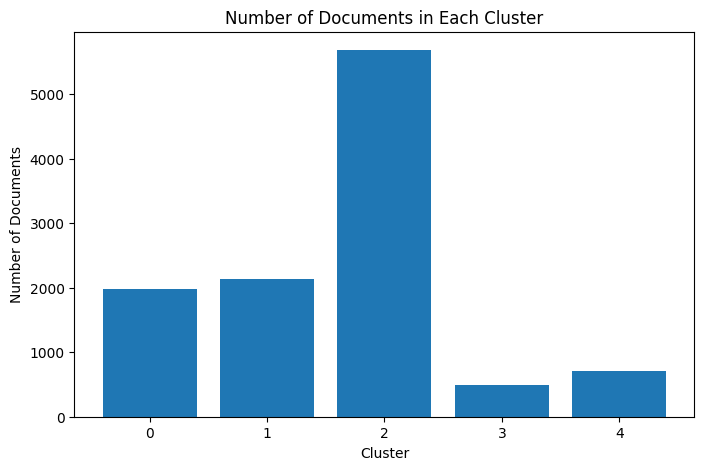

In [17]:
# Visualize the Number of Documents in Each Cluster

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Documents")
plt.title("Number of Documents in Each Cluster")

plt.show()

Using K = 5, K-Means grouped the 11,014 documents into five clusters. The clusters were not evenly distributed, with Cluster 2 containing the most documents (5,685) and Cluster 3 containing the fewest (496)

Part 4 :Understand the Clusters

In [18]:
# Find the Most Important Words in Each Cluster

import numpy as np

# Get the feature names
feature_names = vectorizer.get_feature_names_out()

for cluster_id in range(5):
    # Select documents in the current cluster
    cluster_documents = X_tfidf[clusters == cluster_id]

    # Calculate the average TF-IDF value for each feature
    mean_tfidf = cluster_documents.mean(axis=0).A1

    # Get the indices of the 15 highest-scoring features
    top_indices = mean_tfidf.argsort()[-15:][::-1]

    # Get the corresponding words
    top_words = feature_names[top_indices]

    print(f"\nCluster {cluster_id}")
    print("Top words:", ", ".join(top_words))


Cluster 0
Top words: thanks, windows, drive, card, know, does, use, file, dos, software, advance, hi, files, mail, pc

Cluster 1
Top words: people, don, think, just, government, know, like, key, right, say, make, time, law, did, israel

Cluster 2
Top words: like, just, new, good, edu, car, know, does, time, use, ve, don, think, com, used

Cluster 3
Top words: god, jesus, bible, christians, christ, believe, people, faith, christian, church, say, does, christianity, think, life

Cluster 4
Top words: game, team, games, year, players, season, hockey, play, league, teams, think, baseball, win, nhl, good


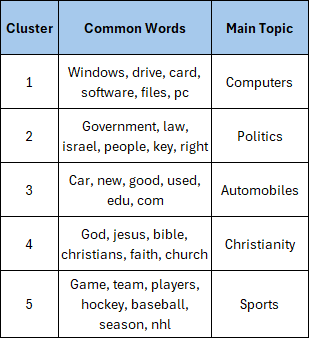

By examining the words in each cluster, the main themes were identified. They are:

- Computers,
- Politics,
- Automobiles,
- Christianity and
- Sports.

Question:
Do the documents within each cluster appear to discuss similar topics?

Answer:
Yes. The documents within each cluster discuss similar topics. For example, the Christianity cluster contains documents about the Bible, God, Jesus, and the church.

Part 5 - Visualize the Clusters

Reduce TF-IDF features to 2 dimensions

In [19]:
# Reduce TF-IDF Features to Two Dimensions

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_2d = svd.fit_transform(X_tfidf)

print("Original TF-IDF shape:", X_tfidf.shape)
print("Reduced data shape:", X_2d.shape)

Original TF-IDF shape: (11014, 10000)
Reduced data shape: (11014, 2)


Create the scatter plot

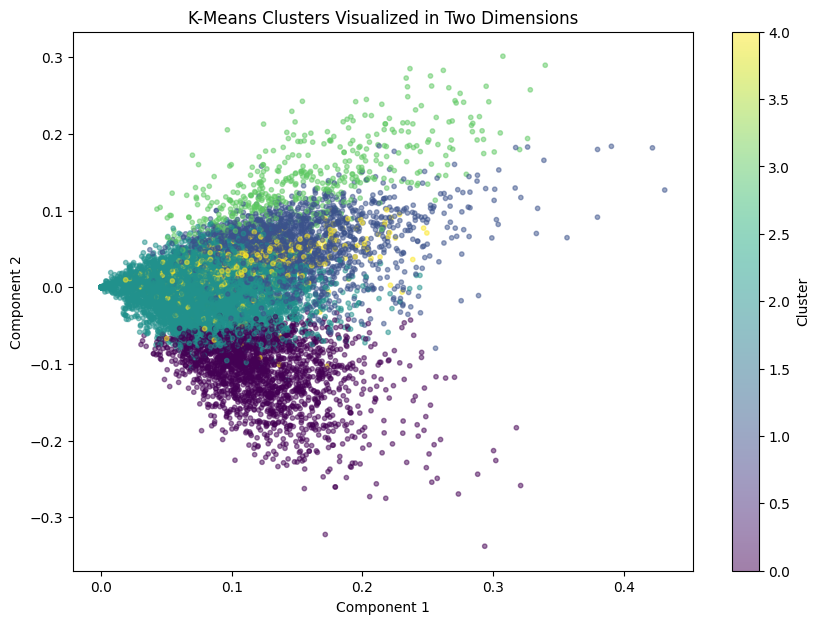

In [20]:
# Visualize the Five K-Means Clusters

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=clusters,
    s=10,
    alpha=0.5
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("K-Means Clusters Visualized in Two Dimensions")
plt.colorbar(label="Cluster")

plt.show()

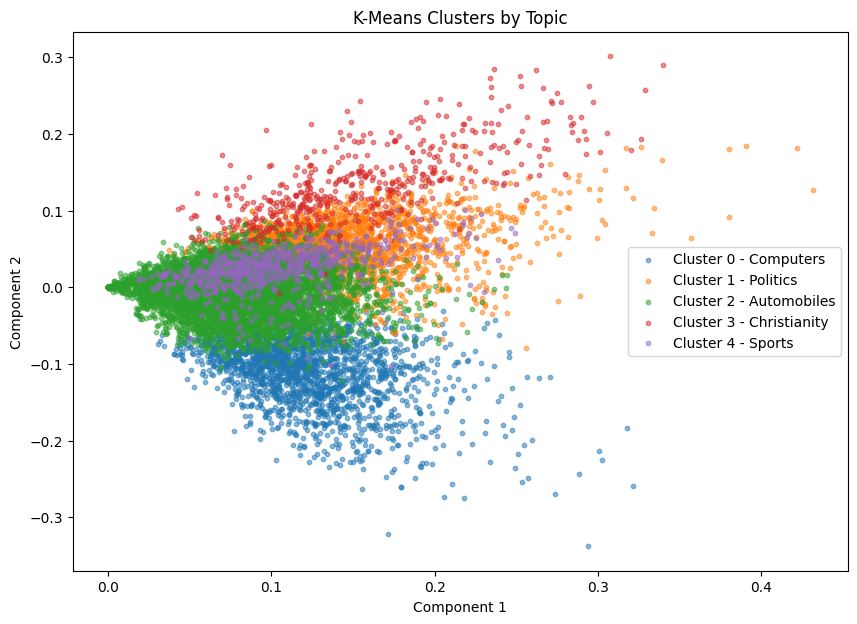

In [21]:
# Visualize the Five K-Means Clusters with Group Names

import matplotlib.pyplot as plt

cluster_names = {
    0: "Computers",
    1: "Politics",
    2: "Automobiles",
    3: "Christianity",
    4: "Sports"
}

plt.figure(figsize=(10, 7))

for cluster_id, group_name in cluster_names.items():
    mask = clusters == cluster_id

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=10,
        alpha=0.5,
        label=f"Cluster {cluster_id} - {group_name}"
    )

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("K-Means Clusters by Topic")
plt.legend()
plt.show()

The graph shows the five groups and their distribution in the two-dimensional space. The Automobiles group appears to be the most represented and relatively concentrated, followed by Sports and Computers.

In comparison, the Politics and Christianity groups are more dispersed. Some overlap can also be observed between the Sports and Automobiles groups, which suggests that some documents from these topics share similar characteristics.

Questions and Answers :

### Final Analysis

1. What is TF-IDF and why is it useful for text data?

TF-IDF is a method that converts text into numerical values based on the importance of words in each document. It is useful because it allows machine learning algorithms like K-Means to work with text data and compare documents.

2. What value of K did you use?
I used K = 5 to group the documents into five clusters.

3. What topics did you find in the clusters?**
The five main topics identified were:
- Computers,
- Politics,
- Automobiles,
- Christianity,
- and Sports.

These topics were identified by examining the most important words in each cluster.

4. Did the documents within each cluster appear similar?

Yes. The documents within each cluster generally appeared to discuss similar topics such as the Christianity cluster contained words such as God, Jesus, Bible, Christ, and church.

5. Were some clusters difficult to interpret?

Yes. Some clusters were more difficult to interpret because they contained general words. For example, Cluster 1 contains words such as people, don, think, just, government, know, like, and key. These words are not clearly related to one central topic and can be found in different topics.

6. What did the PCA visualization show?

The graph shows the five groups, with some groups being more concentrated than others. The Automobiles group appears to be the most represented and concentrated, followed by Sports and Computers. Politics and Christianity are more dispersed. It is also worth noting some overlap between the Sports and Computers groups.

7. What is one limitation of using K-Means for text?

One main limitation is that the number of clusters must be chosen before applying K-Means. Using another value of K may provide different results. In addition, PCA reduces the data to a two-dimensional space for visualization, which can hide some relationships between groups and terms.